## Text Summarization
Take input corpus like brown or gutenberg and summarize using pretrained model
<br>
2 types of summaries - DESCRIPTIVE AND INFORMATIVE
<br>
Add 2 performance metrics for the model 

In [ ]:
# !pip install -q nltk transformers torch evaluate rouge_score

import nltk
from nltk.corpus import gutenberg
from transformers import pipeline
import evaluate

In [ ]:
file_id = 'melville-moby_dick.txt'
raw_text = gutenberg.raw(file_id)
corpus_label = f'Gutenberg: {file_id}'

input_text = raw_text

print('Selected corpus:', corpus_label)
print('Input length:', len(input_text))

Selected corpus: Gutenberg: melville-moby_dick.txt
Input length: 1242990


In [ ]:
# Pretrained abstractive summarizer
summarizer = pipeline('summarization', model='sshleifer/distilbart-cnn-12-6')

safe_input_text = summarizer.tokenizer.decode(
    summarizer.tokenizer.encode(input_text, truncation=True, max_length=1000),
    skip_special_tokens=True
)

descriptive_summary_raw = summarizer(
    f"This text is about: {safe_input_text}",
    max_length=30, 
    min_length=10,
    do_sample=False
)[0]['summary_text']
descriptive_summary = f"This document provides an overview of {descriptive_summary_raw.strip()}."

informative_summary = summarizer(
    safe_input_text,
    max_length=150,
    min_length=80,
    do_sample=False
)[0]['summary_text']

print('DESCRIPTIVE SUMMARY (Topic-focused):\n', descriptive_summary)
print('\nINFORMATIVE SUMMARY (Content-focused):\n', informative_summary)

Device set to use cpu


DESCRIPTIVE SUMMARY (Topic-focused):
 This document provides an overview of This text is about: [Moby Dick by Herman Melville 1851] The text was supplied by a Late Consumptive Us.

INFORMATIVE SUMMARY (Content-focused):
  The whale statements are not for veritable gospel cetology, but for entertaining . As a mere painstaking burrower and grub-worm of a Sub-Sub-Sub appears to have gone through the long .Vaticans and street-stalls of the earth, picking up whatever random references to whales he could find in any book whatsoever . Therefore you must not, in every case at least,take the . higgledy-piggledy whale statements, however authentic, in . However, these extracts are solely valuable or entertaining .


ROUGE-1: 0.2885
ROUGE-L: 0.2612
BLEU   : 0.0044


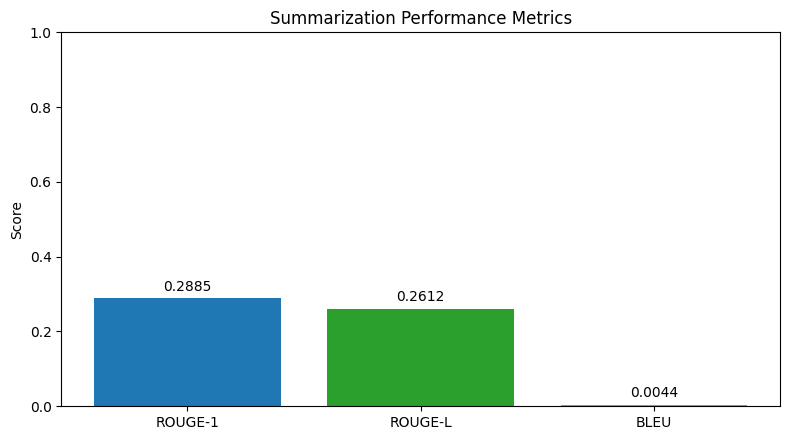

In [ ]:
reference_summary = ' '.join(nltk.sent_tokenize(safe_input_text)[:1024])

# ROUGE
rouge = evaluate.load('rouge')
rouge_scores = rouge.compute(
    predictions=[informative_summary],
    references=[reference_summary]
)

# BLEU
bleu = evaluate.load('bleu')
bleu_scores = bleu.compute(
    predictions=[informative_summary],
    references=[[reference_summary]]
)

rouge1 = round(rouge_scores['rouge1'], 4)
rougeL = round(rouge_scores['rougeL'], 4)
bleu = round(bleu_scores['bleu'], 4)

print('ROUGE-1:', rouge1)
print('ROUGE-L:', rougeL)
print('BLEU   :', bleu)

import matplotlib.pyplot as plt

metric_names = ['ROUGE-1', 'ROUGE-L', 'BLEU']
metric_values = [rouge1, rougeL, bleu]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(metric_names, metric_values, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Summarization Performance Metrics')

for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.4f}', ha='center')

plt.tight_layout()
plt.show()